Part2

In [36]:
import xarray
dset = xarray.open_dataset('./4d5e2a30f04d79319dbee61889033c56/reanalysis-era5-single-levels-timeseries-sfcbpmz9osy.nc')
dset

<xarray.Dataset> Size: 842kB
Dimensions:     (valid_time: 52608)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 421kB 2020-01-01 ... 2025-12-31T2...
    latitude    float64 8B ...
    longitude   float64 8B ...
Data variables:
    t2m         (valid_time) float32 210kB ...
    tp          (valid_time) float32 210kB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [37]:
import numpy as np
t2m = np.array(dset.variables['t2m'])
tp = np.array(dset.variables['tp'])
latitude = np.array(dset.variables['latitude'])
longitude = np.array(dset.variables['longitude'])
time_dt = np.array(dset.variables['valid_time'])

In [38]:
t2m = t2m- 273.15
tp = tp * 1000

In [39]:
if t2m.ndim == 4:
    t2m = np.nanmean(t2m, axis=1)
    tp = np.nanmean(tp, axis=1)

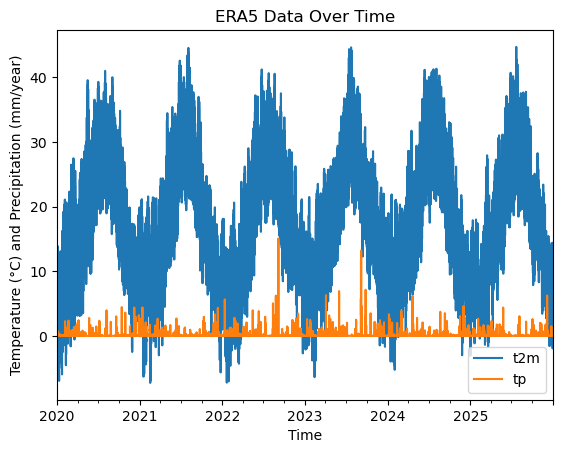

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

df_era5 = pd.DataFrame(index=time_dt)
df_era5['t2m'] = t2m
df_era5['tp'] = tp

df_era5.plot()
## add labels and title
plt.xlabel('Time')
plt.ylabel('Temperature (°C) and Precipitation (mm/year)')
plt.title('ERA5 Data Over Time')
plt.savefig('era5_plot.png', dpi=300)
plt.show()

In [41]:
annual_precip = df_era5['tp'].resample('YE').mean()*24*365.25
mean_annual_precip = np.nanmean(annual_precip)

Part3

In [44]:
# daily
tmin = df_era5['t2m'].resample('D').min().values
tmax = df_era5['t2m'].resample('D').max().values
tmean = df_era5['t2m'].resample('D').mean().values
lat = 21.25
doy = df_era5['t2m'].resample('D').mean().index.dayofyear

In [45]:
import tools
pe = tools.hargreaves_samani_1982(tmin, tmax, tmean, lat, doy)
pe

array([2.2034216, 1.7948797, 1.7447797, ..., 1.7701094, 2.0785983,
       1.4302319], shape=(2192,), dtype=float32)

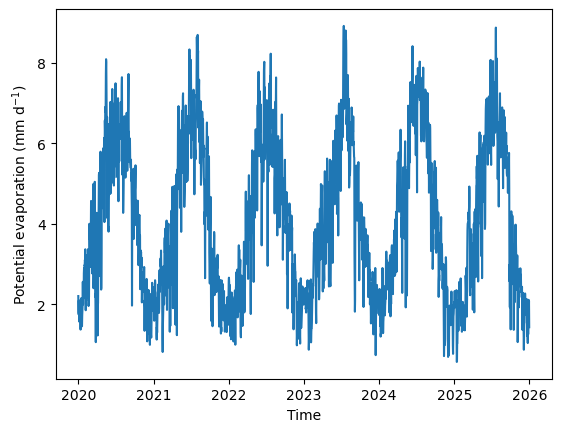

In [46]:
ts_index = df_era5['t2m'].resample('D').mean().index

plt.figure()
plt.plot(ts_index, pe, label='Potential Evaporation')
plt.xlabel('Time')
plt.ylabel('Potential evaporation (mm d$^{-1}$)')

plt.savefig('potential_evaporation.png', dpi=300)
plt.show()

In [47]:
# 3️⃣ Convert to ANNUAL TOTAL (mm yr^-1)
pe_series = df_era5['t2m'].resample('D').mean().copy()
pe_series.iloc[:] = pe  # 把日PE放回时间序列

pe_annual = pe_series.resample('YE').sum()

# 4️⃣ Mean Annual PE (mm yr^-1)
mean_pe_yearly = np.nanmean(pe_annual)

mean_pe_yearly

np.float32(1498.0118)